CNN 2D + ResNet50 Transfer Learning

CELL 1 — Install & Import Libraries


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (confusion_matrix, classification_report,
                              accuracy_score)

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Dense, Dropout, GlobalAveragePooling2D,
                                     BatchNormalization)
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print("TensorFlow Version:", tf.__version__)
print("All libraries loaded ✅")

TensorFlow Version: 2.21.0
All libraries loaded ✅


CELL 2 — Set Dataset Path

In [ ]:
BASE_DIR = r"C:\Users\ABHINAV\Desktop\Heart_PA\chest_xray"

# If notebook and chest_xray folder are in same directory:
# BASE_DIR = "chest_xray"

TRAIN_DIR = os.path.join(BASE_DIR, 'train')
TEST_DIR  = os.path.join(BASE_DIR, 'test')
VAL_DIR   = os.path.join(BASE_DIR, 'val')

# Verify paths
for path, name in [(TRAIN_DIR,'Train'), (TEST_DIR,'Test'), (VAL_DIR,'Val')]:
    normal    = len(os.listdir(os.path.join(path, 'NORMAL')))
    pneumonia = len(os.listdir(os.path.join(path, 'PNEUMONIA')))
    print(f"{name:5} → NORMAL: {normal:4}  PNEUMONIA: {pneumonia}")

print("\n✅ Dataset paths verified!")

Train → NORMAL: 1341  PNEUMONIA: 3875
Test  → NORMAL:  234  PNEUMONIA: 390
Val   → NORMAL:    8  PNEUMONIA: 8

✅ Dataset paths verified!


CELL 3 — Explore & Visualize Dataset


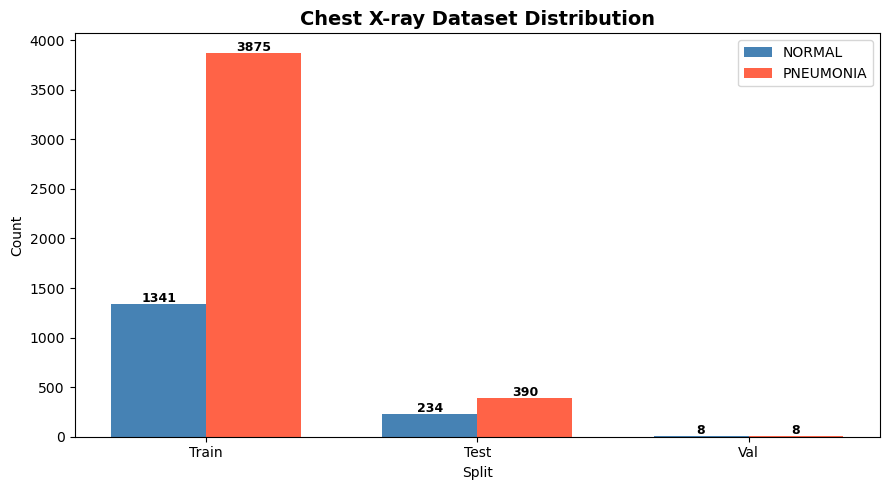

In [3]:
# Class distribution
splits     = ['Train', 'Test', 'Val']
normals    = []
pneumonias = []

for path in [TRAIN_DIR, TEST_DIR, VAL_DIR]:
    normals.append(len(os.listdir(os.path.join(path, 'NORMAL'))))
    pneumonias.append(len(os.listdir(os.path.join(path, 'PNEUMONIA'))))

x     = np.arange(len(splits))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, normals,    width, label='NORMAL',    color='steelblue')
bars2 = ax.bar(x + width/2, pneumonias, width, label='PNEUMONIA', color='tomato')

ax.set_title('Chest X-ray Dataset Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Split')
ax.set_ylabel('Count')
ax.set_xticks(x)
ax.set_xticklabels(splits)
ax.legend()

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 20,
            str(int(bar.get_height())),
            ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('resnet_dataset_distribution.png', dpi=150)
plt.show()

CELL 3 — Explore & Visualize Dataset


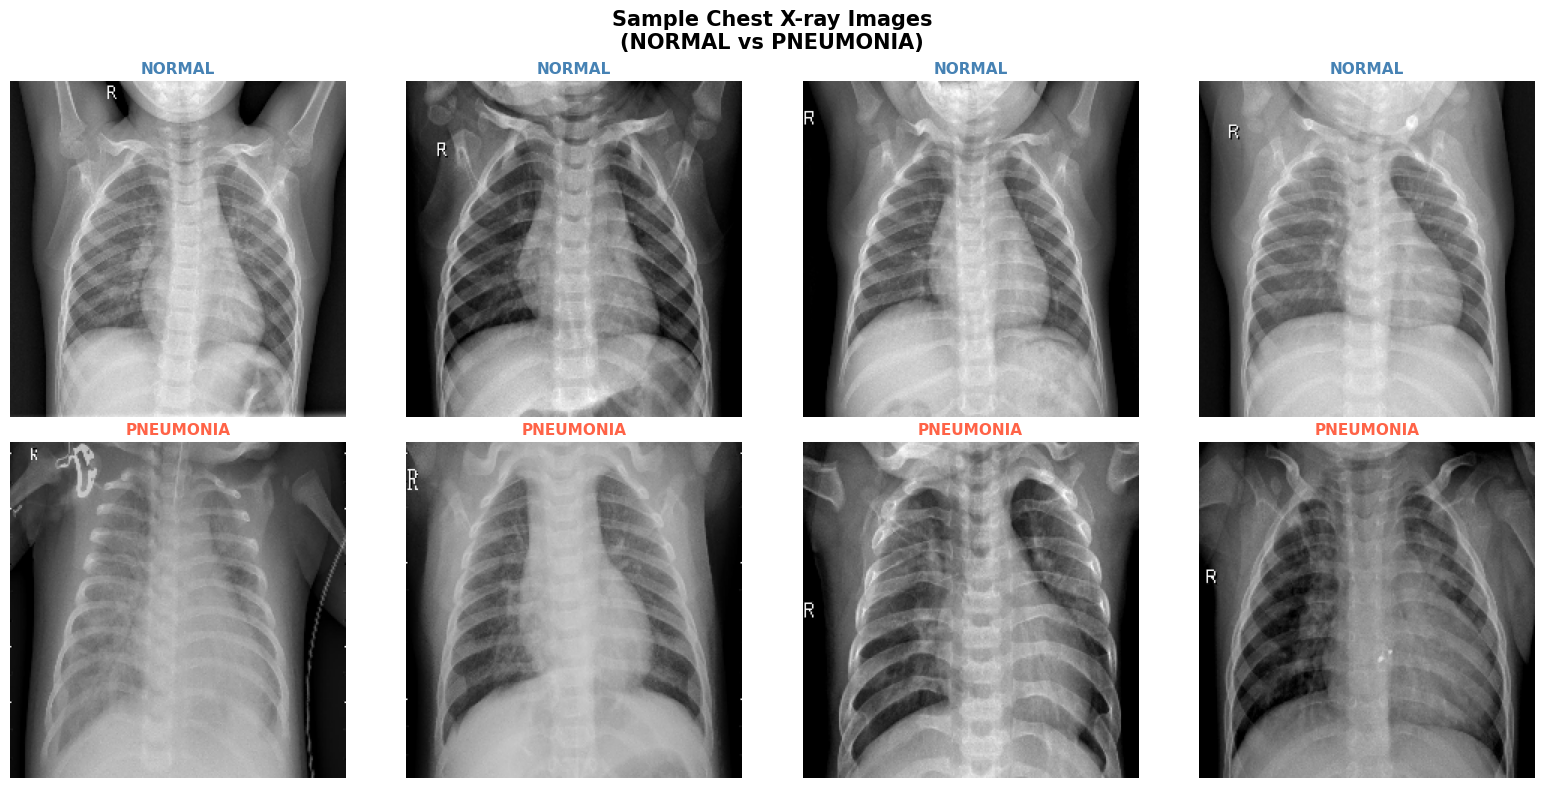

In [4]:
from tensorflow.keras.preprocessing.image import load_img

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
classes   = ['NORMAL', 'PNEUMONIA']
colors    = ['steelblue', 'tomato']

for row, cls in enumerate(classes):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    images  = os.listdir(cls_dir)[:4]
    for col, img_name in enumerate(images):
        img = load_img(os.path.join(cls_dir, img_name),
                       target_size=(224, 224))
        axes[row][col].imshow(img)
        axes[row][col].set_title(cls, fontweight='bold',
                                  color=colors[row], fontsize=11)
        axes[row][col].axis('off')

plt.suptitle('Sample Chest X-ray Images\n(NORMAL vs PNEUMONIA)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('resnet_sample_xrays.png', dpi=150)
plt.show()

 CELL 5 — Data Preprocessing & Augmentation

In [5]:
# Image settings
IMG_SIZE   = (224, 224)   # ResNet50 requires 224x224
BATCH_SIZE = 16            # ✅ Small batch = less RAM on CPU

# ✅ Training data — with augmentation to prevent overfitting
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

# ✅ Test/Val data — only rescale, no augmentation
test_datagen = ImageDataGenerator(rescale=1./255)

# Generators
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False             # ✅ Important — keep order for evaluation
)

val_gen = test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("\nClass Indices:", train_gen.class_indices)
print("Train batches:", len(train_gen))
print("Test  batches:", len(test_gen))
print("✅ Data generators ready!")

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Found 16 images belonging to 2 classes.

Class Indices: {'NORMAL': 0, 'PNEUMONIA': 1}
Train batches: 326
Test  batches: 39
✅ Data generators ready!


 CELL 5 — Data Preprocessing & Augmentation

In [6]:
# -----------------------------------------------
# TRANSFER LEARNING CONCEPT:
# ResNet50 pretrained on ImageNet (1M images)
# We freeze base layers → only train top layers
# This saves time and gives better accuracy
# -----------------------------------------------

# Load ResNet50 without top classification layer
base_model = ResNet50(
    weights='imagenet',      # ✅ Pretrained weights
    include_top=False,       # ✅ Remove ImageNet classifier
    input_shape=(224, 224, 3)
)

# ✅ Freeze base model layers — don't retrain them
base_model.trainable = False

print(f"ResNet50 base layers : {len(base_model.layers)}")
print(f"Trainable layers     : {len([l for l in base_model.layers if l.trainable])}")

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)     # Reduce spatial dimensions
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)  # Binary: Normal vs Pneumonia

# Final model
model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\n✅ ResNet50 Model built!")
print(f"Total params     : {model.count_params():,}")
print(f"Trainable params : {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 800s 8us/step
ResNet50 base layers : 175
Trainable layers     : 0

✅ ResNet50 Model built!
Total params     : 24,153,473
Trainable params : 561,665


CELL 7 — Train Phase 1 (Frozen Base)

In [7]:
# Phase 1: Train only the top layers
print("=" * 50)
print("PHASE 1: Training top layers only (base frozen)")
print("=" * 50)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history1 = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\n✅ Phase 1 Training Complete!")

PHASE 1: Training top layers only (base frozen)
Epoch 1/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 318s 949ms/step - accuracy: 0.8646 - loss: 0.3086 - val_accuracy: 0.6250 - val_loss: 0.7727 - learning_rate: 0.0010
Epoch 2/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 225s 690ms/step - accuracy: 0.8859 - loss: 0.2690 - val_accuracy: 0.6250 - val_loss: 0.8137 - learning_rate: 0.0010
Epoch 3/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 240s 736ms/step - accuracy: 0.8947 - loss: 0.2497 - val_accuracy: 0.7500 - val_loss: 0.8844 - learning_rate: 0.0010
Epoch 4/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 233s 715ms/step - accuracy: 0.9059 - loss: 0.2255 - val_accuracy: 0.7500 - val_loss: 0.7071 - learning_rate: 0.0010
Epoch 5/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 231s 708ms/step - accuracy: 0.9051 - loss: 0.2264 - val_accuracy: 0.7500 - val_loss: 0.9091 - learning_rate: 0.0010
Epoch 6/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 0s 708ms/step - accuracy: 0.9099 - loss: 0.2076
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
326/326 

CELL 8 — Train Phase 1 (unFrozen Base)

In [8]:
# Phase 2: Unfreeze last 20 layers of ResNet50 for fine-tuning
print("=" * 50)
print("PHASE 2: Fine-tuning top ResNet50 layers")
print("=" * 50)

# Unfreeze last 20 layers
for layer in base_model.layers[-20:]:
    layer.trainable = True

# Recompile with lower learning rate
model.compile(
    optimizer=Adam(learning_rate=0.0001),   # ✅ Lower LR for fine-tuning
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop2 = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr2 = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

history2 = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=[early_stop2, reduce_lr2],
    verbose=1
)

print("\n✅ Phase 2 Fine-tuning Complete!")

PHASE 2: Fine-tuning top ResNet50 layers
Epoch 1/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 440s 1s/step - accuracy: 0.8698 - loss: 0.3433 - val_accuracy: 0.5000 - val_loss: 3.5765 - learning_rate: 1.0000e-04
Epoch 2/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 480s 1s/step - accuracy: 0.9107 - loss: 0.2237 - val_accuracy: 0.8125 - val_loss: 0.4596 - learning_rate: 1.0000e-04
Epoch 3/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 513s 2s/step - accuracy: 0.9160 - loss: 0.2135 - val_accuracy: 0.5625 - val_loss: 0.6862 - learning_rate: 1.0000e-04
Epoch 4/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 512s 2s/step - accuracy: 0.9162 - loss: 0.1927 - val_accuracy: 0.6250 - val_loss: 1.9265 - learning_rate: 1.0000e-04
Epoch 5/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9225 - loss: 0.1881
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
326/326 ━━━━━━━━━━━━━━━━━━━━ 459s 1s/step - accuracy: 0.9260 - loss: 0.1794 - val_accuracy: 0.7500 - val_loss: 0.5676 - learning_rate: 1.0000e-04
Epoch 6/10
326/326 ━━━━━

CELL 9 — Merge & Plot Training History

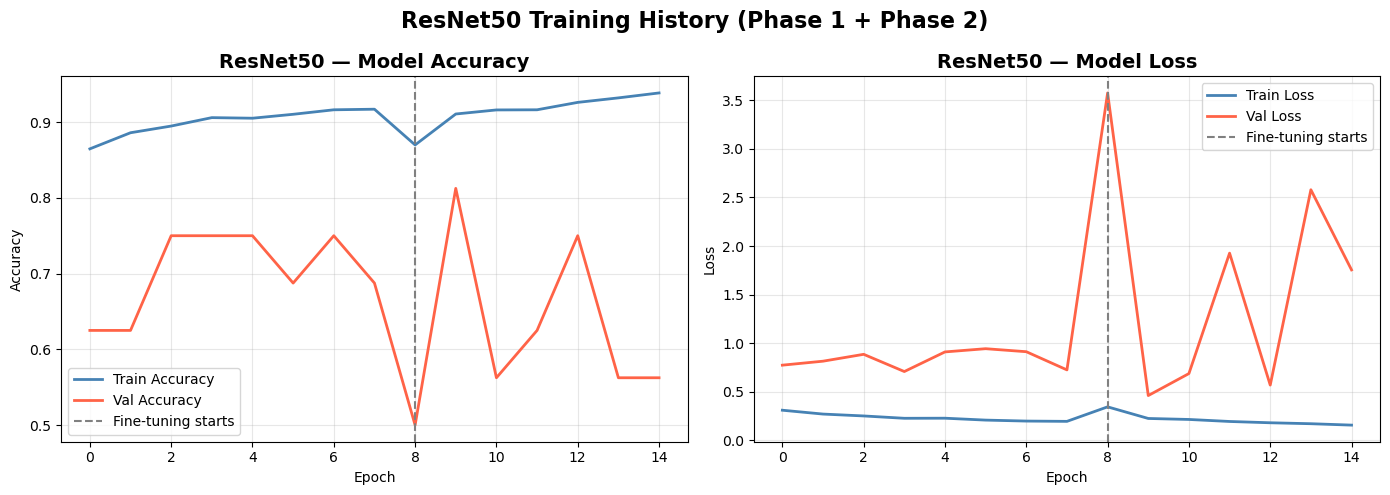

In [9]:
# Combine both phase histories
def combine_history(h1, h2):
    combined = {}
    for key in h1.history:
        combined[key] = h1.history[key] + h2.history[key]
    return combined

history_combined = combine_history(history1, history2)
phase1_epochs    = len(history1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history_combined['accuracy'],
             label='Train Accuracy', color='steelblue', linewidth=2)
axes[0].plot(history_combined['val_accuracy'],
             label='Val Accuracy',   color='tomato',    linewidth=2)
axes[0].axvline(x=phase1_epochs, color='gray',
                linestyle='--', label='Fine-tuning starts')
axes[0].set_title('ResNet50 — Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history_combined['loss'],
             label='Train Loss', color='steelblue', linewidth=2)
axes[1].plot(history_combined['val_loss'],
             label='Val Loss',   color='tomato',    linewidth=2)
axes[1].axvline(x=phase1_epochs, color='gray',
                linestyle='--', label='Fine-tuning starts')
axes[1].set_title('ResNet50 — Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('ResNet50 Training History (Phase 1 + Phase 2)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('resnet_accuracy_loss.png', dpi=150, bbox_inches='tight')
plt.show()

CELL 10 — Evaluate Model

In [10]:
# Evaluate on test set
print("Evaluating on test set...")
test_gen.reset()

y_pred_prob = model.predict(test_gen, verbose=1)
y_pred      = (y_pred_prob > 0.5).astype(int).flatten()
y_true      = test_gen.classes

acc = accuracy_score(y_true, y_pred)
print(f"\n✅ ResNet50 Test Accuracy: {acc*100:.2f}%")

print("\n=== Classification Report ===")
print(classification_report(
    y_true, y_pred,
    target_names=['NORMAL', 'PNEUMONIA']
))

Evaluating on test set...
39/39 ━━━━━━━━━━━━━━━━━━━━ 29s 701ms/step

✅ ResNet50 Test Accuracy: 87.50%

=== Classification Report ===
              precision    recall  f1-score   support

      NORMAL       0.83      0.84      0.83       234
   PNEUMONIA       0.90      0.89      0.90       390

    accuracy                           0.88       624
   macro avg       0.87      0.87      0.87       624
weighted avg       0.88      0.88      0.88       624



CELL 11 — Confusion Matrix

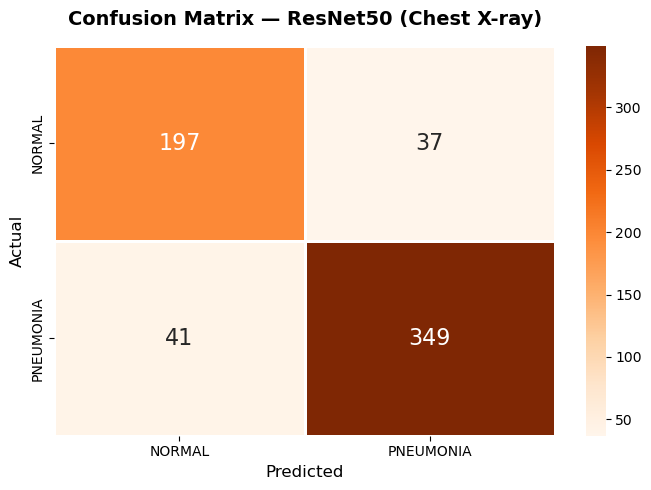

True Positive  (TP): 349
True Negative  (TN): 197
False Positive (FP): 37
False Negative (FN): 41


In [11]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'],
            linewidths=1, linecolor='white',
            annot_kws={"size": 16})

plt.title('Confusion Matrix — ResNet50 (Chest X-ray)',
          fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Actual',    fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.savefig('resnet_confusion_matrix.png', dpi=150)
plt.show()

TP = cm[1][1]; TN = cm[0][0]
FP = cm[0][1]; FN = cm[1][0]
print(f"True Positive  (TP): {TP}")
print(f"True Negative  (TN): {TN}")
print(f"False Positive (FP): {FP}")
print(f"False Negative (FN): {FN}")

CELL 12 — Final All Models Comparison

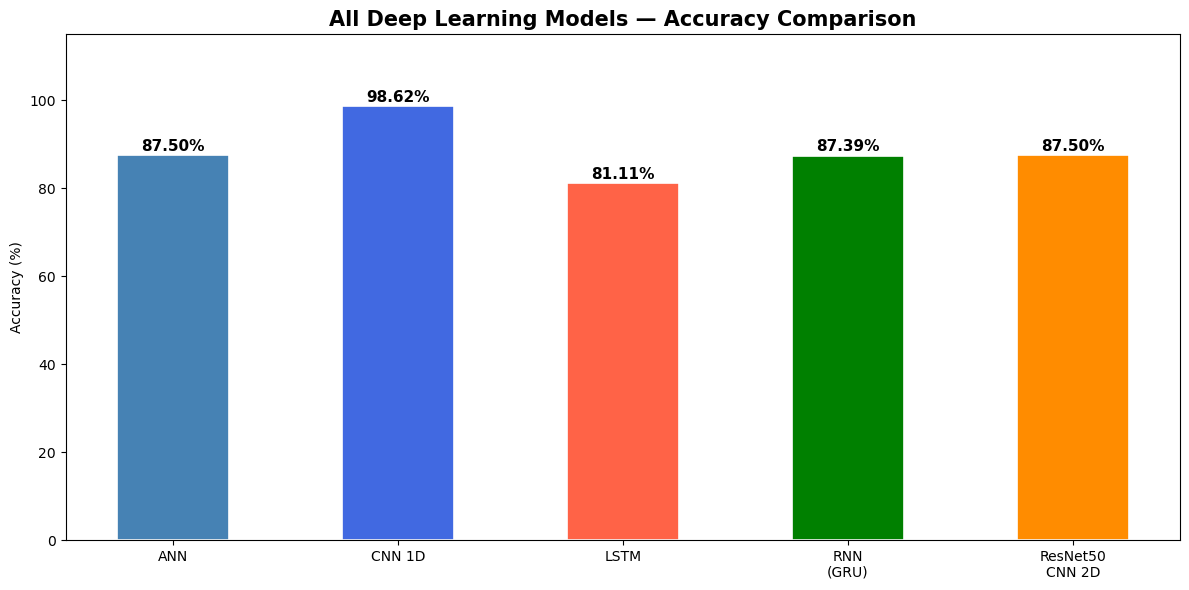

✅ Final comparison chart saved!


In [12]:
# ✅ Update with your actual results
models     = ['ANN', 'CNN 1D', 'LSTM', 'RNN\n(GRU)', 'ResNet50\nCNN 2D']
accuracies = [87.50, 98.62, 81.11, 87.39, acc*100]
colors     = ['steelblue','royalblue','tomato','green','darkorange']

plt.figure(figsize=(12, 6))
bars = plt.bar(models, accuracies, color=colors,
               edgecolor='white', linewidth=1.2, width=0.5)

plt.title('All Deep Learning Models — Accuracy Comparison',
          fontsize=15, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 115)

for bar, val in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{val:.2f}%',
             ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('all_models_comparison.png', dpi=150)
plt.show()
print("✅ Final comparison chart saved!")

CELL 12 — Final All Models Comparison

In [13]:
model.save('resnet50_xray_model.h5')
print("✅ ResNet50 model saved!")
print("\n📁 Output files:")
print("   - resnet_dataset_distribution.png")
print("   - resnet_sample_xrays.png")
print("   - resnet_accuracy_loss.png")
print("   - resnet_confusion_matrix.png")
print("   - all_models_comparison.png  ← Final chart for report!")
print("   - resnet50_xray_model.h5")

✅ ResNet50 model saved!

📁 Output files:
   - resnet_dataset_distribution.png
   - resnet_sample_xrays.png
   - resnet_accuracy_loss.png
   - resnet_confusion_matrix.png
   - all_models_comparison.png  ← Final chart for report!
   - resnet50_xray_model.h5
